In [16]:
# ================================================================
# PPC: Spatial Neighbor Statistic (snow-snow adjacency)
# One-step-ahead
# 5 MODELS:
#   IID / BYM shared / BYM weekly / BYM+cov / BYM weekly+cov
# ================================================================

import numpy as np
import pyreadr
import pickle
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

np.random.seed(1)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 200

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# LOAD DATA + 2PC FILTER
# ------------------------------------------------------------

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]
W = W[keep][:, keep]
S, T = y.shape
print("Using S =", S)

# ------------------------------------------------------------
# TIME COVARIATES
# ------------------------------------------------------------

t_raw = np.arange(1, T+1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])

week = (t_raw - 1) % 52

# ------------------------------------------------------------
# SPATIAL COVARIATES (2pc-consistent)
# ------------------------------------------------------------

lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

elev_df = pd.read_csv(BASE_DIR / "curr_elev.csv")
elev_all = elev_df.iloc[:,3].to_numpy()
elev = elev_all[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_all[keep]
temp = (temp - temp.mean()) / temp.std()

# ------------------------------------------------------------
# LOAD POSTERIORS
# ------------------------------------------------------------

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

bym01 = np.load(BASE_DIR / "bym01.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10.npz")["all_theta"]

bym01_cov = np.load(BASE_DIR / "bym01_cov.npz")["all_theta"]
bym10_cov = np.load(BASE_DIR / "bym10_cov.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]

# ------------------------------------------------------------
# SPATIAL NEIGHBOR STATISTIC
# ------------------------------------------------------------

def neighbor_stat(y_mat):

    total_neighbors = 0
    total_snow = 0

    for t in range(T):

        yt = y_mat[:, t]
        snow_mask = yt == 1
        n_snow = snow_mask.sum()

        if n_snow == 0:
            continue

        total_snow += n_snow

        spatial_counts = W @ yt.astype(int)

        # only count for snow cells
        total_neighbors += spatial_counts[snow_mask].sum()

    return total_neighbors / total_snow

I_obs = neighbor_stat(y)
print("Observed neighbor stat:", I_obs)

# ------------------------------------------------------------
# SIGMOID
# ------------------------------------------------------------

def sigmoid(z):
    z = np.clip(z,-30,30)
    return 1/(1+np.exp(-z))

# ------------------------------------------------------------
# GENERIC SIMULATOR
# ------------------------------------------------------------

def simulate(get_eta):

    draws = np.random.choice(M, N_REP, replace=False)
    stats = np.zeros(N_REP)

    for j, m in enumerate(tqdm(draws)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m,t)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]  # one-step-ahead (observed)

            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

        stats[j] = neighbor_stat(y_rep)

    return stats

# ------------------------------------------------------------
# ETA DEFINITIONS
# ------------------------------------------------------------

def eta_iid(m,t):
    e1 = sum(cov4[t,k]*iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k]*iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1,e2

def eta_bym(m,t):
    e1 = sum(cov8[t,k]*bym01[k*S:(k+1)*S,m] for k in range(8))
    e2 = sum(cov8[t,k]*bym10[k*S:(k+1)*S,m] for k in range(8))
    return e1,e2

def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_week[k*S:(k+1)*S,m]
        beta2 = eta10_week[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_week[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_week[k*52+w,m]
    return e1,e2

def eta_cov(m,t):
    e1,e2 = eta_bym(m,t)
    gamma1 = bym01_cov[8*S:8*S+3,m]
    gamma2 = bym10_cov[8*S:8*S+3,m]
    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])
    return e1+fac@gamma1, e2+fac@gamma2

def eta_week_cov(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_wf[k*S:(k+1)*S,m]
        beta2 = eta10_wf[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_wf[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_wf[k*52+w,m]
    gamma1 = eta01_wf[8*S:8*S+3,m]
    gamma2 = eta10_wf[8*S:8*S+3,m]
    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])
    return e1+fac@gamma1, e2+fac@gamma2

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

print("\nIID")
I_iid = simulate(eta_iid)

# print("\nBYM shared")
# I_bym = simulate(eta_bym)

print("\nBYM weekly")
I_week = simulate(eta_week)

# print("\nBYM + cov")
# I_cov = simulate(eta_cov)

print("\nBYM weekly + cov")
I_week_cov = simulate(eta_week_cov)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

def summarize(name, x):
    print("\n", name)
    print("Mean:", x.mean())
    print("SD:", x.std())
    print("P(stat >= obs):", np.mean(x >= I_obs))

summarize("IID", I_iid)
# summarize("BYM shared", I_bym)
summarize("BYM weekly", I_week)
# summarize("BYM+cov", I_cov)
summarize("BYM weekly+cov", I_week_cov)

Using S = 1557
Observed neighbor stat: 3.2491496268011355

IID


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]



BYM weekly


100%|██████████| 200/200 [03:05<00:00,  1.08it/s]



BYM weekly + cov


100%|██████████| 200/200 [03:09<00:00,  1.05it/s]


 IID
Mean: 2.9699665950009204
SD: 0.0014974132220791222
P(stat >= obs): 0.0

 BYM weekly
Mean: 2.9786851601168824
SD: 0.0015618248237778737
P(stat >= obs): 0.0

 BYM weekly+cov
Mean: 2.979577668670605
SD: 0.001341806165515518
P(stat >= obs): 0.0


Using S = 1557
Observed weekly stat computed.


100%|██████████| 200/200 [03:37<00:00,  1.09s/it]


 IID
Mean range: 0.11920775358269137 3.223328358605878
P-value range: 0.0 0.0

 BYM weekly
Mean range: 0.15190444285423005 3.2237128973112816
P-value range: 0.0 0.0

 BYM weekly+cov
Mean range: 0.14531341952864643 3.2246838557623687
P-value range: 0.0 0.0


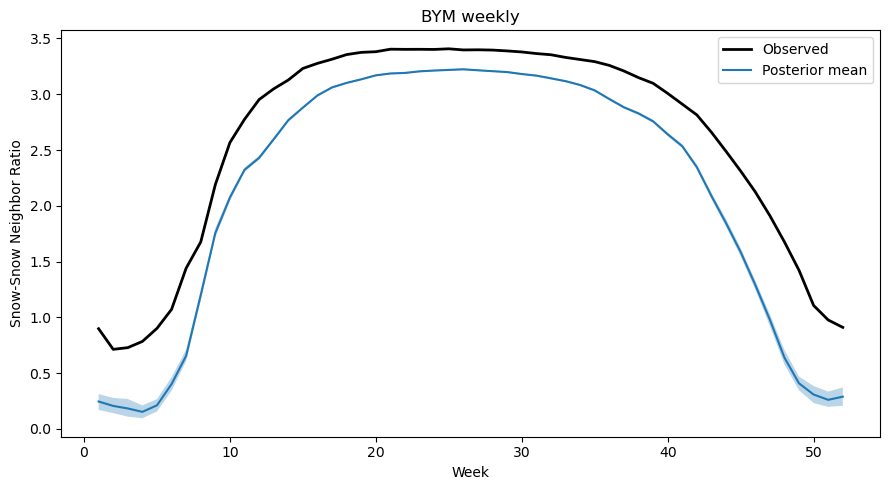

In [17]:
import numpy as np
import pyreadr
import pickle
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt

np.random.seed(1)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 200

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# LOAD DATA + 2PC FILTER
# ------------------------------------------------------------

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]
W = W[keep][:, keep]
S, T = y.shape
print("Using S =", S)

# ------------------------------------------------------------
# TIME STRUCTURE
# ------------------------------------------------------------

t_raw = np.arange(1, T+1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])

week = (t_raw - 1) % 52
week_indices = [np.where(week == w)[0] for w in range(52)]

# ------------------------------------------------------------
# SPATIAL COVARIATES
# ------------------------------------------------------------

lat = (coords[:,1] - coords[:,1].mean()) / coords[:,1].std()

elev = pd.read_csv(BASE_DIR / "curr_elev.csv").iloc[:,3].to_numpy()[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_all[keep]
temp = (temp - temp.mean()) / temp.std()

# ------------------------------------------------------------
# LOAD POSTERIORS
# ------------------------------------------------------------

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

bym01 = np.load(BASE_DIR / "bym01.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10.npz")["all_theta"]

bym01_cov = np.load(BASE_DIR / "bym01_cov.npz")["all_theta"]
bym10_cov = np.load(BASE_DIR / "bym10_cov.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]

# ------------------------------------------------------------
# WEEKLY NEIGHBOR STATISTIC
# ------------------------------------------------------------

def neighbor_stat_weekly(y_mat):

    stats = np.zeros(52)

    for w in range(52):

        total_neighbors = 0
        total_snow = 0

        idx = week_indices[w]

        for t in idx:

            yt = y_mat[:, t]
            snow_mask = yt == 1
            n_snow = snow_mask.sum()

            if n_snow == 0:
                continue

            total_snow += n_snow
            spatial_counts = W @ yt.astype(int)
            total_neighbors += spatial_counts[snow_mask].sum()

        stats[w] = 0 if total_snow == 0 else total_neighbors / total_snow

    return stats


I_obs_week = neighbor_stat_weekly(y)
print("Observed weekly stat computed.")

# ------------------------------------------------------------
# SIGMOID
# ------------------------------------------------------------

def sigmoid(z):
    z = np.clip(z,-30,30)
    return 1/(1+np.exp(-z))

# ------------------------------------------------------------
# GENERIC SIMULATOR
# ------------------------------------------------------------

def simulate_weekly(get_eta):

    draws = np.random.choice(M, N_REP, replace=False)
    stats = np.zeros((52, N_REP))

    for j, m in enumerate(tqdm(draws)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m,t)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]

            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

        stats[:,j] = neighbor_stat_weekly(y_rep)

    return stats

# ------------------------------------------------------------
# ETA DEFINITIONS
# ------------------------------------------------------------

def eta_iid(m,t):
    e1 = sum(cov4[t,k]*iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k]*iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1,e2

def eta_bym(m,t):
    e1 = sum(cov8[t,k]*bym01[k*S:(k+1)*S,m] for k in range(8))
    e2 = sum(cov8[t,k]*bym10[k*S:(k+1)*S,m] for k in range(8))
    return e1,e2

def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_week[k*S:(k+1)*S,m]
        beta2 = eta10_week[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_week[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_week[k*52+w,m]
    return e1,e2

def eta_cov(m,t):
    e1,e2 = eta_bym(m,t)
    gamma1 = bym01_cov[8*S:8*S+3,m]
    gamma2 = bym10_cov[8*S:8*S+3,m]
    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])
    return e1+fac@gamma1, e2+fac@gamma2

def eta_week_cov(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_wf[k*S:(k+1)*S,m]
        beta2 = eta10_wf[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_wf[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_wf[k*52+w,m]
    gamma1 = eta01_wf[8*S:8*S+3,m]
    gamma2 = eta10_wf[8*S:8*S+3,m]
    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])
    return e1+fac@gamma1, e2+fac@gamma2

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

I_iid = simulate_weekly(eta_iid)
# I_bym = simulate_weekly(eta_bym)
I_week = simulate_weekly(eta_week)
# I_cov = simulate_weekly(eta_cov)
I_week_cov = simulate_weekly(eta_week_cov)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

def summarize(name, x):

    mean = x.mean(axis=1)
    lo = np.percentile(x, 2.5, axis=1)
    hi = np.percentile(x, 97.5, axis=1)
    pval = np.mean(x >= I_obs_week[:,None], axis=1)

    print("\n", name)
    print("Mean range:", mean.min(), mean.max())
    print("P-value range:", pval.min(), pval.max())

    return mean, lo, hi, pval


res_iid = summarize("IID", I_iid)
# res_bym = summarize("BYM shared", I_bym)
res_week = summarize("BYM weekly", I_week)
# res_cov = summarize("BYM+cov", I_cov)
res_week_cov = summarize("BYM weekly+cov", I_week_cov)

# ------------------------------------------------------------
# PLOT EXAMPLE
# ------------------------------------------------------------

weeks = np.arange(1,53)

def plot_model(name, res):

    mean, lo, hi, _ = res

    plt.figure(figsize=(9,5))
    plt.plot(weeks, I_obs_week, color="black", linewidth=2, label="Observed")
    plt.plot(weeks, mean, label="Posterior mean")
    plt.fill_between(weeks, lo, hi, alpha=0.3)
    plt.title(name)
    plt.xlabel("Week")
    plt.ylabel("Snow-Snow Neighbor Ratio")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_model("BYM weekly", res_week)

Using S = 1557


100%|██████████| 200/200 [03:56<00:00,  1.18s/it]


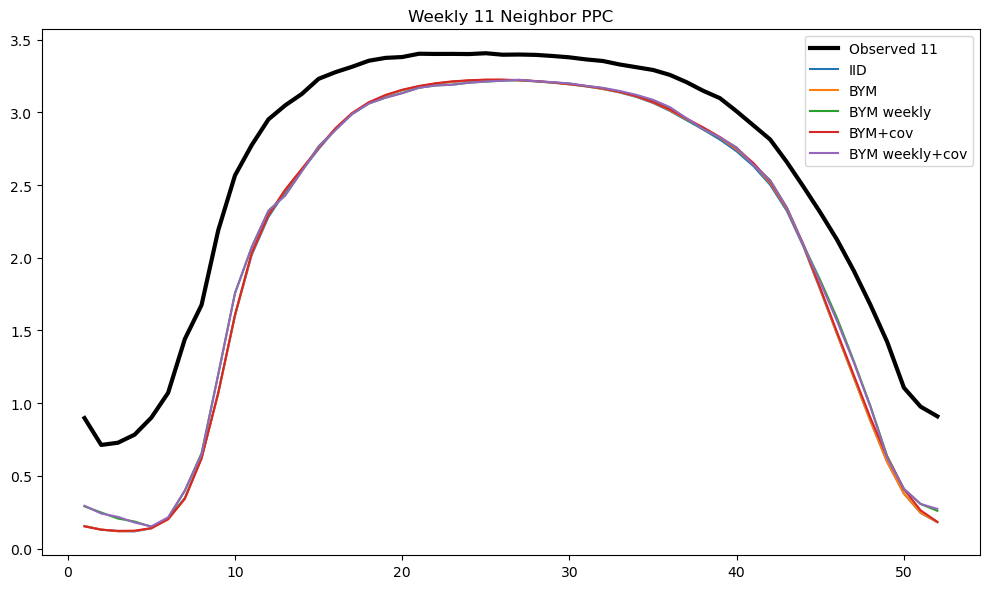

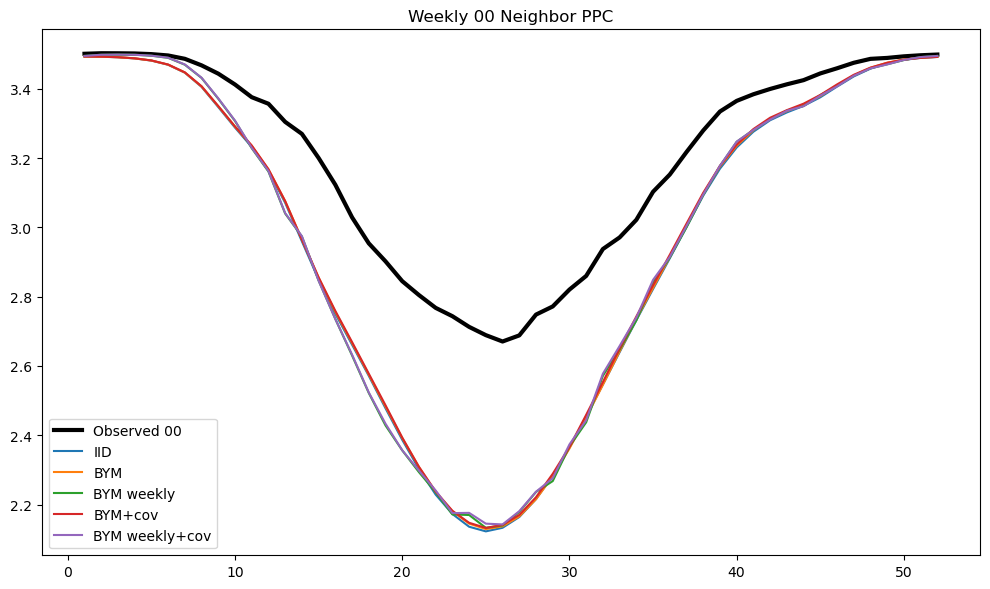

In [ ]:
import numpy as np
import pyreadr
import pickle
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt

np.random.seed(1)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 200

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# LOAD DATA + TWO LARGEST COMPONENTS
# ------------------------------------------------------------

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]
W = W[keep][:, keep]

S, T = y.shape
print("Using S =", S)

# ------------------------------------------------------------
# TIME STRUCTURE
# ------------------------------------------------------------

t_raw = np.arange(1, T+1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])

week = (t_raw - 1) % 52
week_indices = [np.where(week == w)[0] for w in range(52)]

# ------------------------------------------------------------
# SPATIAL COVARIATES
# ------------------------------------------------------------

lat = (coords[:,1] - coords[:,1].mean()) / coords[:,1].std()

elev = pd.read_csv(BASE_DIR / "curr_elev.csv").iloc[:,3].to_numpy()[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_all[keep]
temp = (temp - temp.mean()) / temp.std()

# ------------------------------------------------------------
# LOAD POSTERIORS
# ------------------------------------------------------------

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

bym01 = np.load(BASE_DIR / "bym01.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10.npz")["all_theta"]

bym01_cov = np.load(BASE_DIR / "bym01_cov.npz")["all_theta"]
bym10_cov = np.load(BASE_DIR / "bym10_cov.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]

# ------------------------------------------------------------
# WEEKLY NEIGHBOR STATISTICS
# ------------------------------------------------------------

def neighbor_stat_weekly_11(y_mat):

    stats = np.zeros(52)

    for w in range(52):

        total_neighbors = 0
        total_snow = 0

        for t in week_indices[w]:

            yt = y_mat[:, t]
            snow_mask = yt == 1
            n_snow = snow_mask.sum()

            if n_snow == 0:
                continue

            total_snow += n_snow
            spatial_counts = W @ yt
            total_neighbors += spatial_counts[snow_mask].sum()

        stats[w] = 0 if total_snow == 0 else total_neighbors / total_snow

    return stats


def neighbor_stat_weekly_00(y_mat):

    stats = np.zeros(52)

    for w in range(52):

        total_neighbors = 0
        total_zero = 0

        for t in week_indices[w]:

            yt = y_mat[:, t]
            zero_mask = yt == 0
            n_zero = zero_mask.sum()

            if n_zero == 0:
                continue

            total_zero += n_zero
            spatial_counts = W @ (1 - yt)
            total_neighbors += spatial_counts[zero_mask].sum()

        stats[w] = 0 if total_zero == 0 else total_neighbors / total_zero

    return stats


I_obs_11 = neighbor_stat_weekly_11(y)
I_obs_00 = neighbor_stat_weekly_00(y)

# ------------------------------------------------------------
# SIGMOID
# ------------------------------------------------------------

def sigmoid(z):
    z = np.clip(z,-30,30)
    return 1/(1+np.exp(-z))

# ------------------------------------------------------------
# SIMULATOR (returns both 11 & 00)
# ------------------------------------------------------------

def simulate_weekly(get_eta):

    draws = np.random.choice(M, N_REP, replace=False)

    stats_11 = np.zeros((52, N_REP))
    stats_00 = np.zeros((52, N_REP))

    for j, m in enumerate(tqdm(draws)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m,t-1)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]
            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

        stats_11[:,j] = neighbor_stat_weekly_11(y_rep)
        stats_00[:,j] = neighbor_stat_weekly_00(y_rep)

    return stats_11, stats_00

# ------------------------------------------------------------
# ETA DEFINITIONS
# ------------------------------------------------------------

def eta_iid(m,t):
    e1 = sum(cov4[t,k]*iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k]*iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1,e2

def eta_bym(m,t):
    e1 = sum(cov8[t,k]*bym01[k*S:(k+1)*S,m] for k in range(8))
    e2 = sum(cov8[t,k]*bym10[k*S:(k+1)*S,m] for k in range(8))
    return e1,e2

def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_week[k*S:(k+1)*S,m]
        beta2 = eta10_week[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_week[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_week[k*52+w,m]
    return e1,e2

def eta_cov(m,t):

    # use bym_cov parameters entirely
    theta01 = bym01_cov[:,m]
    theta10 = bym10_cov[:,m]

    # spatial part
    e1 = sum(cov8[t,k] * theta01[k*S:(k+1)*S] for k in range(8))
    e2 = sum(cov8[t,k] * theta10[k*S:(k+1)*S] for k in range(8))

    # global covariates (last 3)
    gamma1 = theta01[8*S:8*S+3]
    gamma2 = theta10[8*S:8*S+3]

    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])

    e1 += fac @ gamma1
    e2 += fac @ gamma2

    return e1,e2

def eta_week_cov(m,t):

    w = week[t]

    theta01 = eta01_wf[:,m]
    theta10 = eta10_wf[:,m]

    e1 = np.zeros(S)
    e2 = np.zeros(S)

    # spatial weekly part
    for k in range(8):

        beta1 = theta01[k*S:(k+1)*S]
        beta2 = theta10[k*S:(k+1)*S]

        scale1 = tau01_wf[k*52 + w, m]
        scale2 = tau10_wf[k*52 + w, m]

        e1 += cov8[t,k] * beta1 * scale1
        e2 += cov8[t,k] * beta2 * scale2

    # global covariates (last 3)
    gamma1 = theta01[8*S:8*S+3]
    gamma2 = theta10[8*S:8*S+3]

    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])

    e1 += fac @ gamma1
    e2 += fac @ gamma2

    return e1,e2

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

I_iid_11, I_iid_00 = simulate_weekly(eta_iid)
# I_bym_11, I_bym_00 = simulate_weekly(eta_bym)
I_week_11, I_week_00 = simulate_weekly(eta_week)
# I_cov_11, I_cov_00 = simulate_weekly(eta_cov)
I_week_cov_11, I_week_cov_00 = simulate_weekly(eta_week_cov)

# ------------------------------------------------------------
# PLOT 11
# ------------------------------------------------------------

weeks = np.arange(1,53)

plt.figure(figsize=(10,6))
plt.plot(weeks, I_obs_11, color="black", linewidth=3, label="Observed 11")
plt.plot(weeks, I_iid_11.mean(axis=1), label="IID")
# plt.plot(weeks, I_bym_11.mean(axis=1), label="BYM")
plt.plot(weeks, I_week_11.mean(axis=1), label="BYM weekly")
# plt.plot(weeks, I_cov_11.mean(axis=1), label="BYM+cov")
plt.plot(weeks, I_week_cov_11.mean(axis=1), label="BYM weekly+cov")
plt.legend()
plt.title("Weekly 11 Neighbor PPC")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 00
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(weeks, I_obs_00, color="black", linewidth=3, label="Observed 00")
plt.plot(weeks, I_iid_00.mean(axis=1), label="IID")
# plt.plot(weeks, I_bym_00.mean(axis=1), label="BYM")
plt.plot(weeks, I_week_00.mean(axis=1), label="BYM weekly")
# plt.plot(weeks, I_cov_00.mean(axis=1), label="BYM+cov")
plt.plot(weeks, I_week_cov_00.mean(axis=1), label="BYM weekly+cov")
plt.legend()
plt.title("Weekly 00 Neighbor PPC")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# DIFFERENCE METRICS
# ------------------------------------------------------------

def compare_model(obs, pred_mean, name):

    diff = pred_mean - obs
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    max_abs = np.max(np.abs(diff))

    print(f"\n{name}")
    print("MAE  :", round(mae,6))
    print("RMSE :", round(rmse,6))


print("\n========== 11 NEIGHBOR ==========")

compare_model(I_obs_11, I_iid_11.mean(axis=1), "IID")
# compare_model(I_obs_11, I_bym_11.mean(axis=1), "BYM")
compare_model(I_obs_11, I_week_11.mean(axis=1), "BYM weekly")
# compare_model(I_obs_11, I_cov_11.mean(axis=1), "BYM cov")
compare_model(I_obs_11, I_week_cov_11.mean(axis=1), "BYM cov weekly")
print("\n========== 00 NEIGHBOR ==========")

compare_model(I_obs_00, I_iid_00.mean(axis=1), "IID")
# compare_model(I_obs_00, I_bym_00.mean(axis=1), "BYM")
compare_model(I_obs_00, I_week_00.mean(axis=1), "BYM weekly")
# compare_model(I_obs_00, I_cov_00.mean(axis=1), "BYM cov")
compare_model(I_obs_00, I_week_cov_00.mean(axis=1), "BYM cov weekly")


========== 11 NEIGHBOR ==========

IID
MAE  : 0.466991
RMSE : 0.544342

BYM
MAE  : 0.463765
RMSE : 0.542338

BYM weekly
MAE  : 0.436909
RMSE : 0.503802

BYM cov
MAE  : 0.458629
RMSE : 0.537054

BYM cov weekly
MAE  : 0.437483
RMSE : 0.504878

========== 00 NEIGHBOR ==========

IID
MAE  : 0.233988
RMSE : 0.30399

BYM
MAE  : 0.23108
RMSE : 0.301171

BYM weekly
MAE  : 0.231851
RMSE : 0.305142

BYM cov
MAE  : 0.228465
RMSE : 0.298398

BYM cov weekly
MAE  : 0.229766
RMSE : 0.302249
